# 1-D Couette Flow: Explicit vs Implicit Finite Volume Method

**Problem:** fluid between two plates (bottom fixed, top moving at `U_top`), governed by

$$\frac{\partial u}{\partial t} = \nu \frac{\partial^2 u}{\partial y^2}$$

- Domain split into `N` cells; velocity stored at cell centres.
- Wall values are applied through a **half-cell flux** (hence the `3u` and `2U_wall` terms).
- Fourier number: $Fo = \nu\,\Delta t/\Delta y^2$. **Explicit** is stable only for $Fo \le 0.5$; **implicit** is stable for any $\Delta t$.
- Steady state is the straight line $u = U_{top}\,y/H$.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

%matplotlib inline

H, U_bottom, U_top, nu = 1.0, 0.0, 1.0, 0.01
t_check, t_end = 20.0, 200.0     # t_check: transient comparison, t_end: (near) steady state

# ---- change these for the single run ----
N = 20            # number of cells
dt_exp = 0.075    # explicit dt  (Fo = 0.3 here)
dt_imp = 1.0      # implicit dt

## Solvers

In [2]:
def centres(N):
    return (np.arange(N) + 0.5) * H / N

def exact(y, t, terms=400):
    """Analytic transient solution (Fourier series)."""
    u = U_bottom + (U_top - U_bottom) * y / H
    for n in range(1, terms + 1):
        u += (2 * (U_top - U_bottom) * (-1)**n / (n * np.pi)
              * np.sin(n * np.pi * y / H) * np.exp(-n**2 * np.pi**2 * nu * t / H**2))
    return u

def explicit(N, dt, t):
    """Forward Euler. Returns (u, Fo, steps)."""
    dy = H / N
    steps = int(np.ceil(t / dt)); dt = t / steps      # make dt fit t exactly
    Fo = nu * dt / dy**2
    u = np.zeros(N)
    with np.errstate(all="ignore"):                   # silence overflow when unstable
        for _ in range(steps):
            old = u.copy()
            u[1:-1] = old[1:-1] + Fo * (old[2:] - 2 * old[1:-1] + old[:-2])
            u[0]    = old[0]    + Fo * (old[1]  - 3 * old[0]    + 2 * U_bottom)
            u[-1]   = old[-1]   + Fo * (old[-2] - 3 * old[-1]   + 2 * U_top)
    return u, Fo, steps

def implicit(N, dt, t):
    """Backward Euler, tridiagonal system solved each step. Returns (u, Fo, steps)."""
    dy = H / N
    steps = int(np.ceil(t / dt)); dt = t / steps
    Fo = nu * dt / dy**2
    ab = np.zeros((3, N))                             # banded storage of the tridiagonal matrix
    ab[0, 1:] = -Fo; ab[2, :-1] = -Fo
    ab[1, :] = 1 + 2 * Fo
    ab[1, [0, -1]] = 1 + 3 * Fo                       # wall cells
    u = np.zeros(N)
    for _ in range(steps):
        b = u.copy(); b[0] += 2 * Fo * U_bottom; b[-1] += 2 * Fo * U_top
        u = solve_banded((1, 1), ab, b)
    return u, Fo, steps

def err(u, y, t):
    """Max error vs exact solution; nan if the run blew up."""
    e = np.max(np.abs(u - exact(y, t)))
    return e if np.isfinite(e) and e < 10 else np.nan

## Single run (steady state, t = 200)

N = 20, dy = 0.0500
explicit: dt = 0.07499, steps = 2667, Fo = 0.3000, steady error = 1.65e-09
implicit: dt = 1.00000, steps = 200, Fo = 4.0000, steady error = 4.40e-09


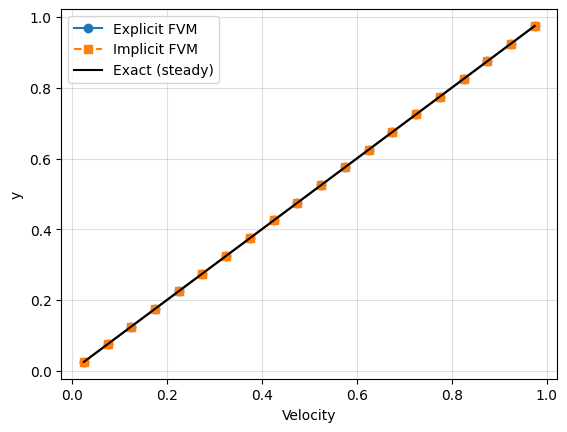

In [3]:
y = centres(N)
ue, Fe, se = explicit(N, dt_exp, t_end)
ui, Fi, si = implicit(N, dt_imp, t_end)

print(f"N = {N}, dy = {H/N:.4f}")
print(f"explicit: dt = {t_end/se:.5f}, steps = {se}, Fo = {Fe:.4f}, steady error = {np.nanmax(np.abs(ue - y)):.2e}")
print(f"implicit: dt = {t_end/si:.5f}, steps = {si}, Fo = {Fi:.4f}, steady error = {np.max(np.abs(ui - y)):.2e}")

plt.plot(ue, y, "o-",  label="Explicit FVM")
plt.plot(ui, y, "s--", label="Implicit FVM")
plt.plot(y,  y, "k-",  label="Exact (steady)")
plt.xlabel("Velocity"); plt.ylabel("y"); plt.grid(alpha=0.4); plt.legend(); plt.show()

## Study 1: number of cells N
Explicit uses Fo = 0.3, implicit uses dt = 0.1. Error is measured against the exact transient at `t_check`.

In [4]:
Ns = [10, 20, 40, 80]
rows = []
for n in Ns:
    yy = centres(n)
    dtx = 0.3 * (H / n)**2 / nu
    t0 = time.time(); ue, _, se = explicit(n, dtx, t_check); te = time.time() - t0
    t0 = time.time(); ui, _, si = implicit(n, 0.1, t_check); ti = time.time() - t0
    rows.append((n, err(ue, yy, t_check), err(ui, yy, t_check), se, si, te, ti))

print(f"{'N':>4} {'err exp':>10} {'err imp':>10} {'steps exp':>10} {'steps imp':>10} {'time exp':>9} {'time imp':>9}")
for r in rows:
    print(f"{r[0]:>4} {r[1]:>10.2e} {r[2]:>10.2e} {r[3]:>10} {r[4]:>10} {r[5]:>9.3f} {r[6]:>9.3f}")

   N    err exp    err imp  steps exp  steps imp  time exp  time imp
  10   7.78e-04   2.66e-03         67        200     0.002     0.016
  20   1.96e-04   1.31e-03        267        200     0.004     0.012
  40   4.91e-05   9.74e-04       1067        200     0.014     0.010
  80   1.23e-05   8.89e-04       4267        200     0.065     0.011


## Study 2: explicit time step (N = 20)
Sweep Fo across the stability limit of 0.5 (`nan` = unstable).

In [5]:
yy = centres(20); dy = H / 20
Fo_list = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.52, 0.6]
exp_rows = []
for Fo in Fo_list:
    ue, _, se = explicit(20, Fo * dy**2 / nu, t_check)
    exp_rows.append((Fo, t_check / se, se, err(ue, yy, t_check)))

print(f"{'Fo':>6} {'dt':>9} {'steps':>7} {'error':>10}")
for r in exp_rows: print(f"{r[0]:>6.2f} {r[1]:>9.5f} {r[2]:>7} {r[3]:>10.2e}")

    Fo        dt   steps      error
  0.05   0.01250    1600   3.43e-04
  0.10   0.02500     800   2.35e-04
  0.20   0.05000     400   1.93e-05
  0.30   0.07491     267   1.96e-04
  0.40   0.10000     200   4.13e-04
  0.50   0.12500     160   3.19e-02
  0.52   0.12987     154        nan
  0.60   0.14925     134        nan


## Study 3: implicit time step (N = 20)
Large dt stays stable but loses transient accuracy; the steady state is still reached.

In [6]:
dts = [0.05, 0.1, 0.25, 0.5, 1, 2, 5, 10]
imp_rows = []
for d in dts:
    ui, Fi, si = implicit(20, d, t_check)
    uf, _, _   = implicit(20, d, t_end)
    imp_rows.append((d, Fi, si, err(ui, yy, t_check), np.max(np.abs(uf - yy))))

print(f"{'dt':>6} {'Fo':>7} {'steps':>6} {'err t=%g' % t_check:>10} {'steady err':>11}")
for r in imp_rows: print(f"{r[0]:>6g} {r[1]:>7.2f} {r[2]:>6} {r[3]:>10.2e} {r[4]:>11.2e}")

    dt      Fo  steps   err t=20  steady err
  0.05    0.20    400   8.82e-04    1.86e-09
   0.1    0.40    200   1.31e-03    1.95e-09
  0.25    1.00     80   2.60e-03    2.25e-09
   0.5    2.00     40   4.73e-03    2.83e-09
     1    4.00     20   8.95e-03    4.40e-09
     2    8.00     10   1.72e-02    9.86e-09
     5   20.00      4   4.05e-02    7.03e-08
    10   40.00      2   7.55e-02    7.05e-07


## Plots

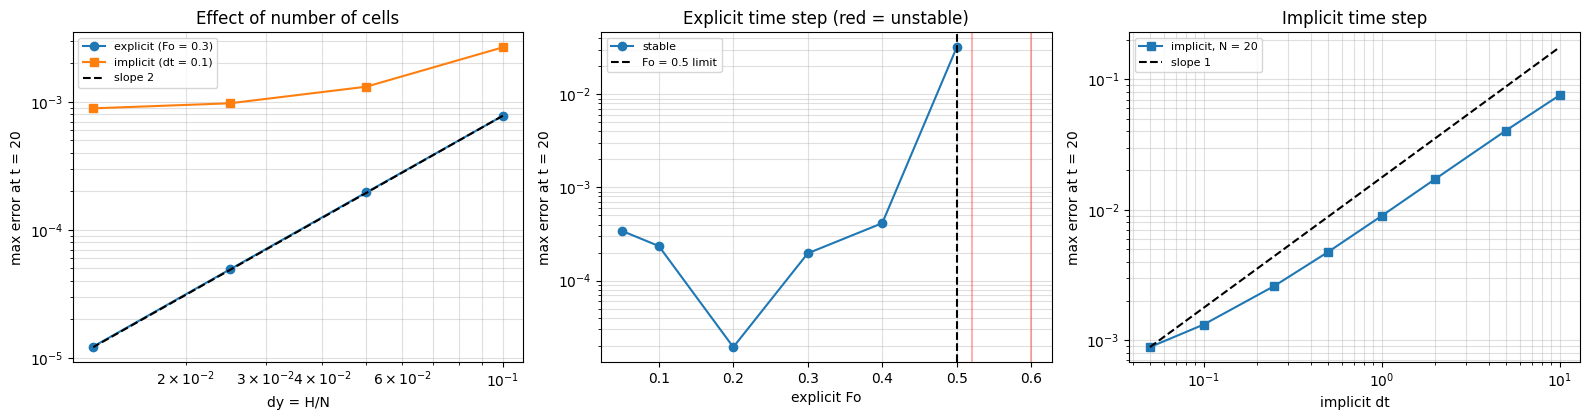

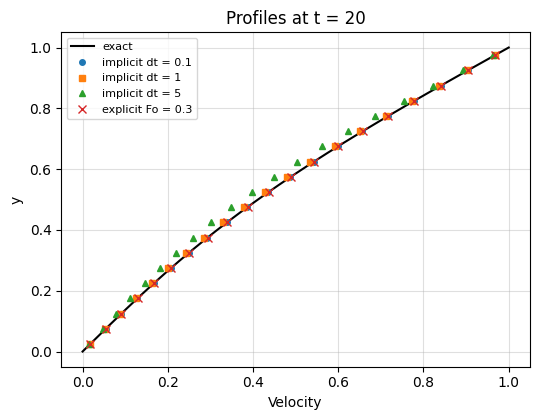

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))

# (1) error vs dy: both schemes should follow slope 2
dys = [1 / r[0] for r in rows]
ax[0].loglog(dys, [r[1] for r in rows], "o-", label="explicit (Fo = 0.3)")
ax[0].loglog(dys, [r[2] for r in rows], "s-", label="implicit (dt = 0.1)")
ax[0].loglog(dys, [rows[0][1] * (d / dys[0])**2 for d in dys], "k--", label="slope 2")
ax[0].set(xlabel="dy = H/N", ylabel=f"max error at t = {t_check:g}", title="Effect of number of cells")

# (2) explicit: error vs Fo, unstable runs marked red
ok = [r for r in exp_rows if np.isfinite(r[3])]
ax[1].semilogy([r[0] for r in ok], [r[3] for r in ok], "o-", label="stable")
for r in exp_rows:
    if not np.isfinite(r[3]): ax[1].axvline(r[0], color="r", alpha=0.3)
ax[1].axvline(0.5, color="k", ls="--", label="Fo = 0.5 limit")
ax[1].set(xlabel="explicit Fo", ylabel=f"max error at t = {t_check:g}", title="Explicit time step (red = unstable)")

# (3) implicit: error vs dt, first order in time
ax[2].loglog(dts, [r[3] for r in imp_rows], "s-", label="implicit, N = 20")
ax[2].loglog(dts, [imp_rows[0][3] * d / dts[0] for d in dts], "k--", label="slope 1")
ax[2].set(xlabel="implicit dt", ylabel=f"max error at t = {t_check:g}", title="Implicit time step")

for a in ax: a.grid(alpha=0.4, which="both"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

# velocity profiles at t_check
plt.figure(figsize=(5.5, 4.3))
ys = np.linspace(0, H, 200)
plt.plot(exact(ys, t_check), ys, "k-", label="exact")
for d, m in [(0.1, "o"), (1, "s"), (5, "^")]:
    plt.plot(implicit(20, d, t_check)[0], yy, m, ms=4, label=f"implicit dt = {d:g}")
plt.plot(explicit(20, 0.3 * dy**2 / nu, t_check)[0], yy, "x", label="explicit Fo = 0.3")
plt.xlabel("Velocity"); plt.ylabel("y"); plt.title(f"Profiles at t = {t_check:g}")
plt.grid(alpha=0.4); plt.legend(fontsize=8); plt.tight_layout(); plt.show()